# E-CUP 2026: базовый анализ ручной разметки товарных пар

Цель отчёта — понять качество и структуру доступной ручной разметки,
оценить силу дешёвых эвристик и сформировать план экспериментов для
cross-encoder, лёгких моделей и ансамбля.

Анализ использует только `data/items_human.parquet` и
`data/matches.parquet`. Набор с 11 млн LLM-размеченных пар пока не
скачан и в расчёты не входит. Все значения ниже получены из локальных
parquet-файлов, а не из описания соревнования.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.metrics import average_precision_score

ROOT = next(
    candidate
    for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / "pyproject.toml").exists()
)
sys.path.insert(0, str(ROOT / "src"))

from product_matching.eda import (
    attribute_key_summary,
    build_pair_features,
    cross_validated_light_baseline,
    graph_summary,
    hard_examples,
    load_human_data,
    macro_average_precision,
    pair_category_summary,
    univariate_feature_scores,
    validate_human_data,
)

DATA_DIR = ROOT / "data"
REPORT_DIR = ROOT / "reports"
REPORT_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 100)
sns.set_theme(style="whitegrid", context="notebook")
COLORS = {"negative": "#64748b", "positive": "#f97316", "model": "#0f766e"}

## 1. Загрузка и целостность данных

In [2]:
items, matches = load_human_data(DATA_DIR)
integrity = validate_human_data(items, matches)
display(integrity.to_frame())
display(items.head(3))
display(matches.head(3))

display(Markdown(
    f'''
    **Фактический объём:** {len(items):,} карточек и {len(matches):,} пар.
    Все ID уникальны, ссылки из пар разрешаются, пропусков, self-pairs и
    повторяющихся неупорядоченных пар нет. Метка принимает значения
    {integrity['target_values']}.
    '''.replace(",", " ")
))

,value
items,711304
pairs,365654
unique_item_ids,711304
item_null_cells,0
pair_null_cells,0
duplicate_item_ids,0
duplicate_unordered_pairs,0
self_pairs,0
missing_id1_references,0
missing_id2_references,0


,id,name,attributes,category
0,197,victor reinz прокладка впускного коллектора арт. 703315700,"{""артикул"":""703315700"",""бренд"":""victor reinz"",""партномер (артикул производителя)"":""703315700"",""т...",Автотовары
1,415,"stellox диск тормозной, арт. 8500892sx","{""артикул"":""stellox_8500892sx"",""место установки"":""передние"",""толщина тормозного диска, мм"":""28"",...",Автотовары
2,427,комплект подшипника ступицы колеса lynxauto,"{""артикул производителя"":"""",""бренд"":""lynxauto"",""примечание"":""внешний вид изделия может отличатьс...",Автотовары


,id1,id2,target
0,32,188978721454,0.0
1,34,197568543106,0.0
2,37,661425040668,0.0



    **Фактический объём:** 711 304 карточек и 365 654 пар.
    Все ID уникальны  ссылки из пар разрешаются  пропусков  self-pairs и
    повторяющихся неупорядоченных пар нет. Метка принимает значения
    (0.0  1.0).
    

## 2. Категории и дисбаланс классов

,items,pairs,positives,positive_rate,negatives
category,,,,,
Аптека,35620,18285,1328,7.3%,16957
Обувь,35936,18362,1813,9.9%,16549
Одежда,45878,23357,2751,11.8%,20606
Ювелирные изделия,34759,18695,2317,12.4%,16378
Мебель,35505,18366,2756,15.0%,15610
Галантерея и аксессуары,35434,17984,3015,16.8%,14969
Электроника,34455,18681,3227,17.3%,15454
Автотовары,37752,19010,3326,17.5%,15684
Строительство и ремонт,36088,18102,3929,21.7%,14173


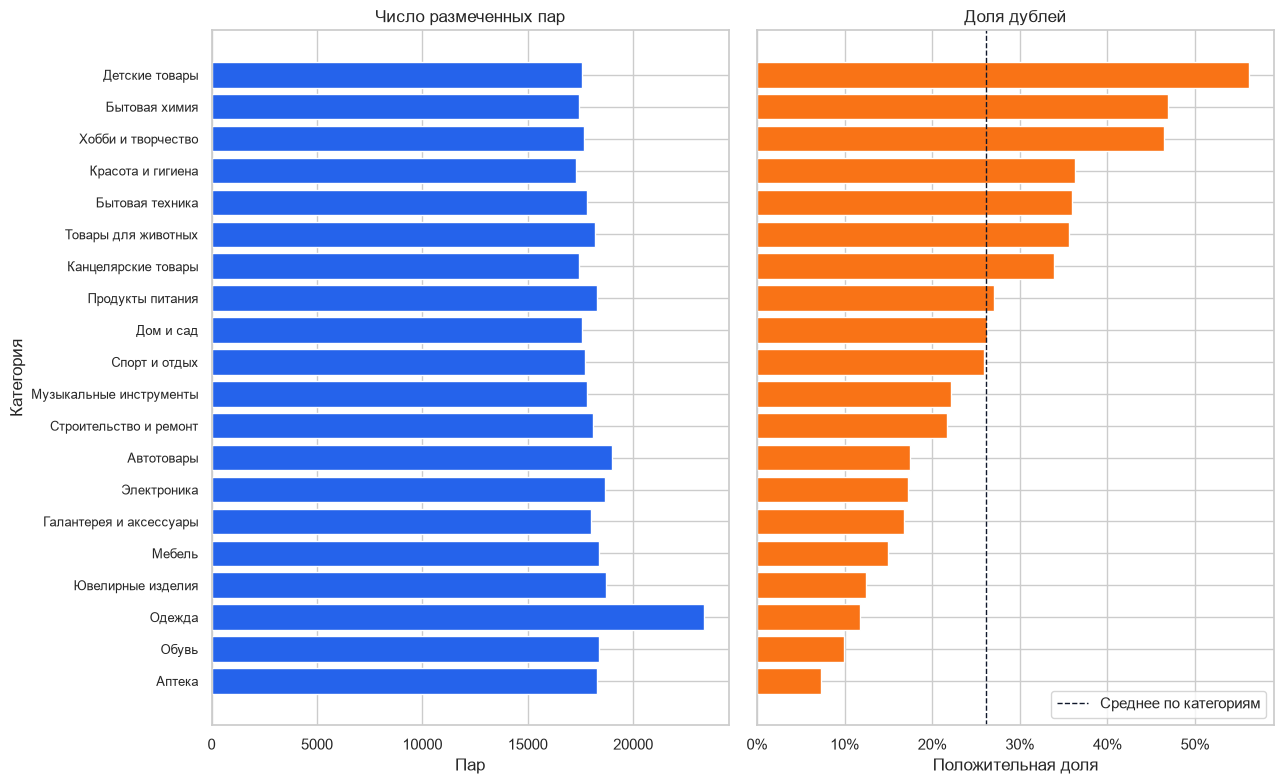


    Все пары находятся **внутри одной категории** (межкатегорийных пар:
    0). При этом доля положительного класса меняется
    от **7.3%** до
    **56.2%**. Это делает обычный
    micro/overall AP недостаточным: отбор моделей, early stopping и подбор
    ансамбля нужно вести по macro AP из 20 category-wise AP. AP константного
    ранжирования здесь равен средней prevalence: **0.2611**.
    

In [3]:
category_summary, pair_categories, cross_category_pairs = pair_category_summary(items, matches)
display(category_summary.style.format({"positive_rate": "{:.1%}"}))

plot_data = category_summary.sort_values("positive_rate")
fig, axes = plt.subplots(1, 2, figsize=(13, 8), sharey=True)
axes[0].barh(plot_data.index, plot_data["pairs"], color="#2563eb")
axes[0].set(title="Число размеченных пар", xlabel="Пар", ylabel="Категория")
axes[0].tick_params(axis="y", labelsize=9)
axes[1].barh(plot_data.index, plot_data["positive_rate"], color=COLORS["positive"])
axes[1].axvline(plot_data["positive_rate"].mean(), color="#0f172a", ls="--", lw=1,
                label="Среднее по категориям")
axes[1].set(title="Доля дублей", xlabel="Положительная доля", ylabel="")
axes[1].xaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
axes[1].legend(loc="lower right")
fig.tight_layout()
plt.show()

prevalence_macro = category_summary["positive_rate"].mean()
display(Markdown(
    f'''
    Все пары находятся **внутри одной категории** (межкатегорийных пар:
    {cross_category_pairs}). При этом доля положительного класса меняется
    от **{category_summary['positive_rate'].min():.1%}** до
    **{category_summary['positive_rate'].max():.1%}**. Это делает обычный
    micro/overall AP недостаточным: отбор моделей, early stopping и подбор
    ансамбля нужно вести по macro AP из 20 category-wise AP. AP константного
    ранжирования здесь равен средней prevalence: **{prevalence_macro:.4f}**.
    '''
))

## 3. Поля карточек и JSON-атрибуты

,name_chars,attributes_chars
count,711304.0,711304.0
mean,57.7,442.3
std,30.4,608.2
min,1.0,2.0
1%,11.0,27.0
10%,24.0,97.0
50%,54.0,353.0
90%,94.0,852.0
95%,113.0,1070.0
99%,158.0,1686.0


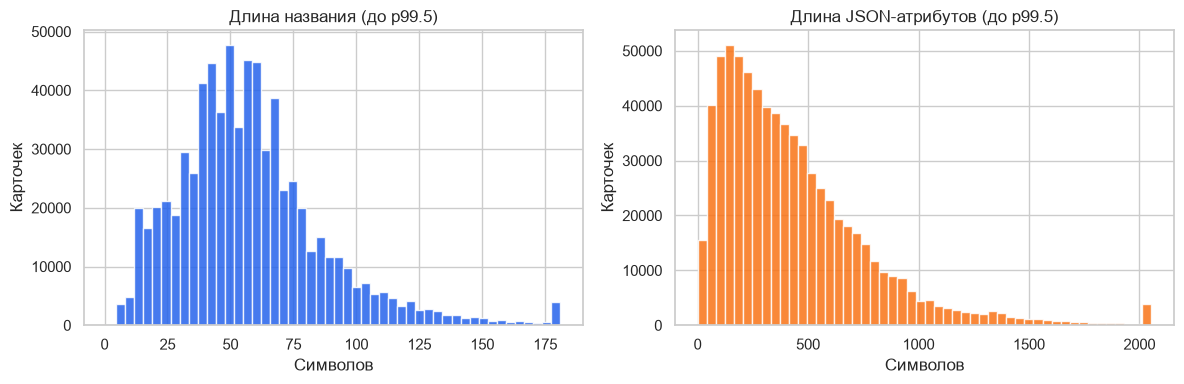

In [4]:
length_summary = pd.DataFrame({
    "name_chars": items["name"].str.len().describe(percentiles=[.01, .1, .5, .9, .95, .99]),
    "attributes_chars": items["attributes"].str.len().describe(percentiles=[.01, .1, .5, .9, .95, .99]),
})
display(length_summary.round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for axis, column, title, color in [
    (axes[0], "name", "Длина названия", "#2563eb"),
    (axes[1], "attributes", "Длина JSON-атрибутов", COLORS["positive"]),
]:
    values = items[column].str.len().clip(upper=items[column].str.len().quantile(.995))
    axis.hist(values, bins=50, color=color, alpha=.85)
    axis.set(title=f"{title} (до p99.5)", xlabel="Символов", ylabel="Карточек")
fig.tight_layout()
plt.show()

,value
invalid_json_rows,0.0000
empty_attribute_objects,72.0000
mean_keys_per_item,12.6082
median_keys_per_item,11.0000
p95_keys_per_item,27.0000


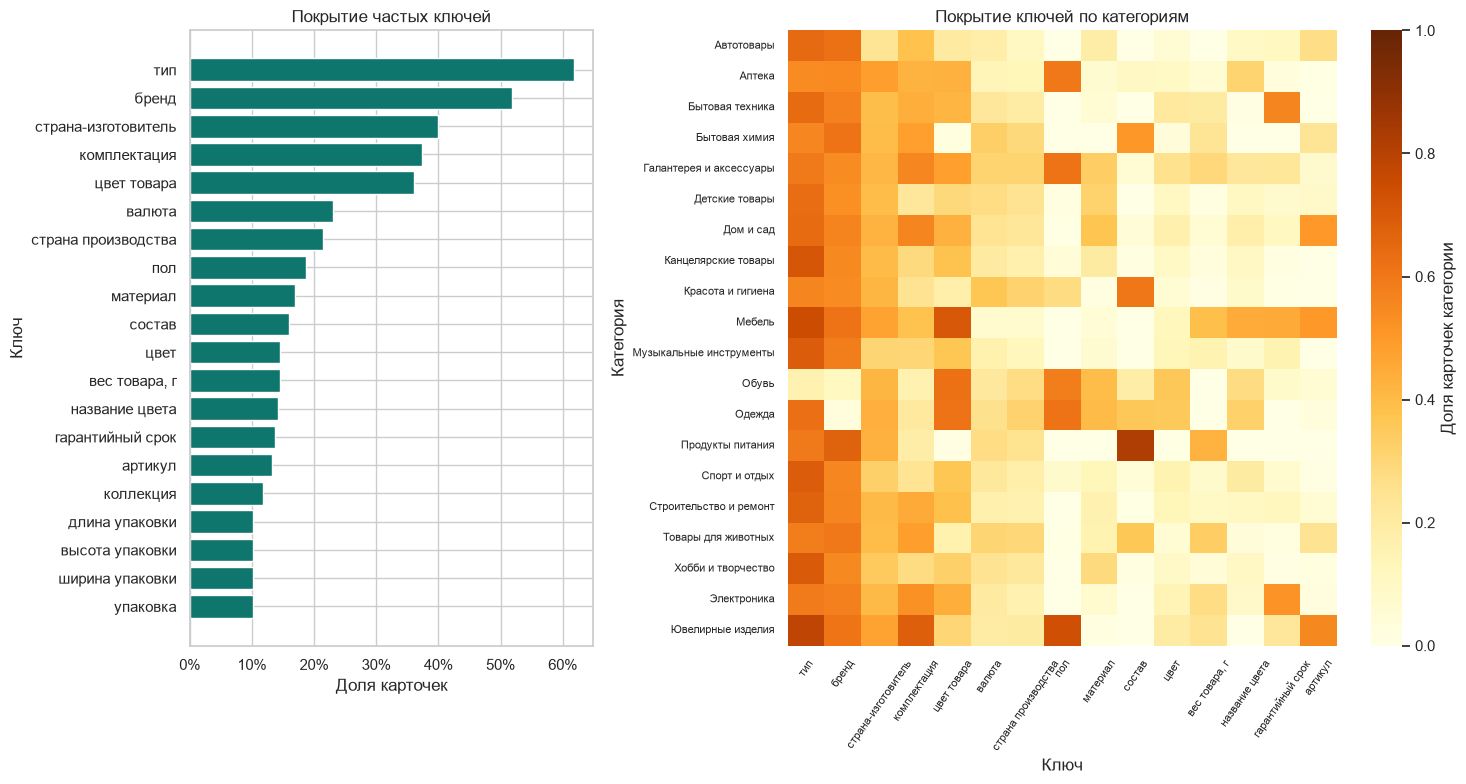


    Все `attributes` валидны как JSON-объекты; пустых объектов —
    **72**. Медиана —
    **11** ключей на карточку 
    однако словари заметно различаются между категориями. Поэтому полезнее
    сериализовать атрибуты как пары `ключ: значение` и учить модель понимать
    ключ  чем склеивать только значения. Для лёгкой ветки нужны
    category-specific признаки и нормализация синонимов ключей.
    

In [5]:
top_attribute_keys, attribute_coverage, attribute_quality = attribute_key_summary(items, top_n=20)
display(attribute_quality.to_frame())

fig, axes = plt.subplots(1, 2, figsize=(15, 8), gridspec_kw={"width_ratios": [1, 1.7]})
top_plot = top_attribute_keys.sort_values("coverage")
axes[0].barh(top_plot.index, top_plot["coverage"], color=COLORS["model"])
axes[0].xaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
axes[0].set(title="Покрытие частых ключей", xlabel="Доля карточек", ylabel="Ключ")

sns.heatmap(
    attribute_coverage[top_attribute_keys.index[:15]],
    cmap="YlOrBr", vmin=0, vmax=1, ax=axes[1],
    cbar_kws={"label": "Доля карточек категории"},
)
axes[1].set(title="Покрытие ключей по категориям", xlabel="Ключ", ylabel="Категория")
axes[1].tick_params(axis="x", rotation=55, labelsize=8)
axes[1].tick_params(axis="y", labelsize=8)
fig.tight_layout()
plt.show()

display(Markdown(
    f'''
    Все `attributes` валидны как JSON-объекты; пустых объектов —
    **{int(attribute_quality['empty_attribute_objects']):,}**. Медиана —
    **{attribute_quality['median_keys_per_item']:.0f}** ключей на карточку,
    однако словари заметно различаются между категориями. Поэтому полезнее
    сериализовать атрибуты как пары `ключ: значение` и учить модель понимать
    ключ, чем склеивать только значения. Для лёгкой ветки нужны
    category-specific признаки и нормализация синонимов ключей.
    '''.replace(",", " ")
))

## 4. Структура графа пар

Ребро — размеченная пара, вершина — товар. Компоненты связности используются
как группы в кросс-валидации: ни один товар и его соседние пары не переходят
между train и validation.

In [6]:
pair_data = build_pair_features(items, matches)
graph_stats, component_groups = graph_summary(len(items), pair_data)
display(graph_stats.to_frame())

display(Markdown(
    f'''
    **{graph_stats['degree_one_share']:.1%}** товаров встречаются ровно в
    одной паре; максимальная степень — {int(graph_stats['maximum_item_degree'])}.
    Компоненты по всем рёбрам имеют медианный размер
    {graph_stats['median_all_edge_component_size']:.0f} и максимум
    {int(graph_stats['maximum_all_edge_component_size'])}. Внутри компонент,
    собранных только по положительным рёбрам, не найдено отрицательных рёбер
    ({int(graph_stats['negative_edges_inside_positive_components'])}). Это
    хороший sanity check транзитивности ручной разметки, хотя маленькие
    компоненты не позволяют считать его полной проверкой.
    '''
))

Built features for 100,000/365,654 pairs


Built features for 200,000/365,654 pairs


Built features for 300,000/365,654 pairs


,value
items_with_degree_one,695084.000000
degree_one_share,0.977197
maximum_item_degree,23.000000
all_edge_components,345654.000000
median_all_edge_component_size,2.000000
maximum_all_edge_component_size,30.000000
positive_components,92293.000000
maximum_positive_component_size,16.000000
negative_edges_inside_positive_components,0.000000



    **97.7%** товаров встречаются ровно в
    одной паре; максимальная степень — 23.
    Компоненты по всем рёбрам имеют медианный размер
    2 и максимум
    30. Внутри компонент,
    собранных только по положительным рёбрам, не найдено отрицательных рёбер
    (0). Это
    хороший sanity check транзитивности ручной разметки, хотя маленькие
    компоненты не позволяют считать его полной проверкой.
    

## 5. Насколько сильны дешёвые признаки

,pairs_with_signal,positive_rate_with_signal,positive_rate_without_signal
signal,,,
name_exact,5401,39.5%,25.5%
identifier_overlap,81681,35.0%,23.0%
brand_equal,29780,25.6%,25.7%
brand_conflict,26587,24.4%,25.8%


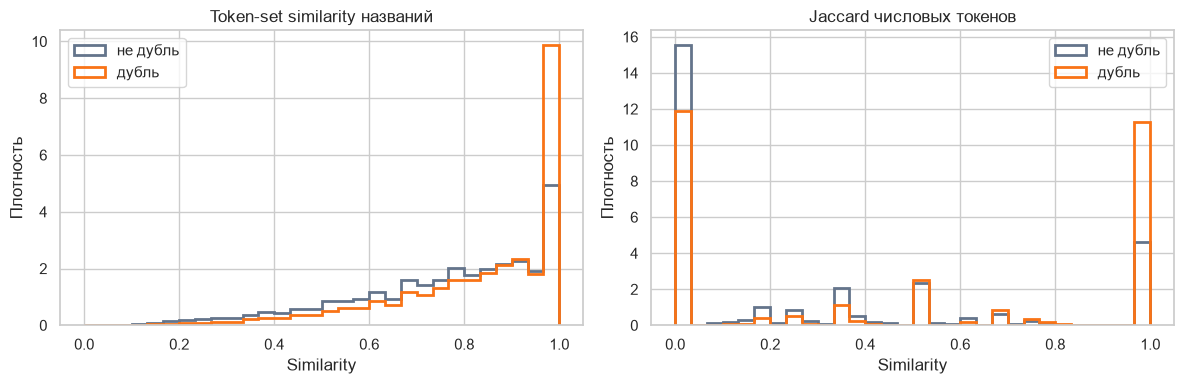

In [7]:
conditional_rows = []
for column in ["name_exact", "identifier_overlap", "brand_equal", "brand_conflict"]:
    mask = pair_data.features[column].astype(bool).to_numpy()
    conditional_rows.append({
        "signal": column,
        "pairs_with_signal": int(mask.sum()),
        "positive_rate_with_signal": pair_data.targets[mask].mean() if mask.any() else np.nan,
        "positive_rate_without_signal": pair_data.targets[~mask].mean(),
    })
conditional = pd.DataFrame(conditional_rows).set_index("signal")
display(conditional.style.format({
    "positive_rate_with_signal": "{:.1%}",
    "positive_rate_without_signal": "{:.1%}",
}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for axis, column, title in [
    (axes[0], "name_token_set_ratio", "Token-set similarity названий"),
    (axes[1], "numeric_jaccard", "Jaccard числовых токенов"),
]:
    for target, label, color in [(0, "не дубль", COLORS["negative"]), (1, "дубль", COLORS["positive"])]:
        values = pair_data.features.loc[pair_data.targets == target, column]
        axis.hist(values, bins=30, density=True, histtype="step", lw=2, label=label, color=color)
    axis.set(title=title, xlabel="Similarity", ylabel="Плотность")
    axis.legend()
fig.tight_layout()
plt.show()

,macro_ap,overall_ap
feature,,
name_token_set_ratio,0.3630,0.3513
numeric_jaccard,0.3369,0.3590
name_token_sort_ratio,0.3215,0.3104
name_ratio,0.3060,0.3080
identifier_overlap,0.2951,0.2851
attr_value_conflict_ratio,0.2949,0.3111
attr_value_match_ratio,0.2711,0.2561
name_exact,0.2696,0.2599
brand_equal,0.2664,0.2567


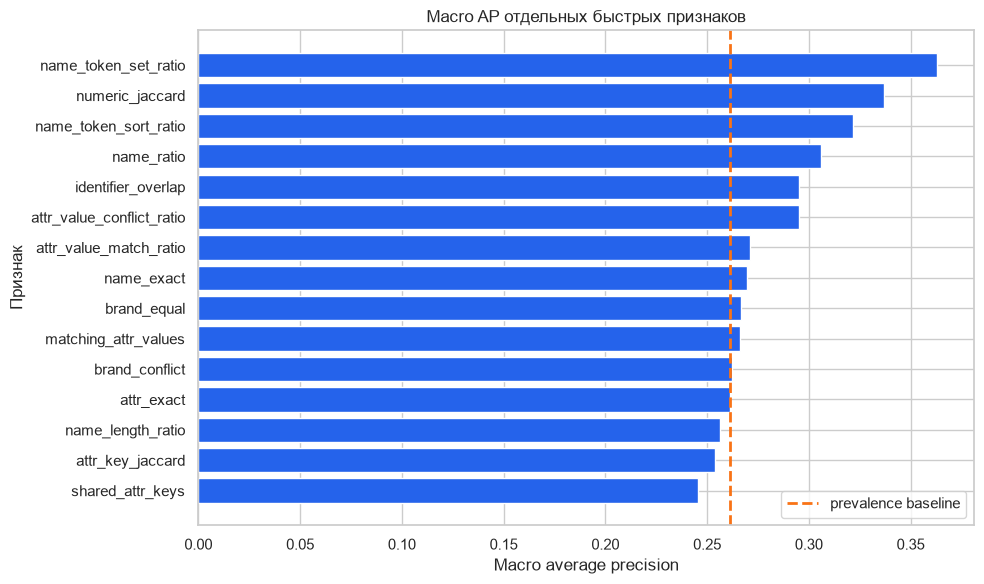


    Лучший одиночный сигнал — `name_token_set_ratio` с macro AP
    **0.3630**. Точное совпадение названий
    встречается в 5 401
    парах  но лишь
    39.5% из них
    положительны. Значит  правила вида «одинаковое имя ⇒ дубль» опасны:
    размеры  комплектации и иные варианты товара остаются критичными.
    

In [8]:
feature_scores = univariate_feature_scores(pair_data)
display(feature_scores.style.format("{:.4f}"))

fig, ax = plt.subplots(figsize=(10, 6))
plot_scores = feature_scores.sort_values("macro_ap")
ax.barh(plot_scores.index, plot_scores["macro_ap"], color="#2563eb")
ax.axvline(prevalence_macro, color=COLORS["positive"], ls="--", lw=2, label="prevalence baseline")
ax.set(title="Macro AP отдельных быстрых признаков", xlabel="Macro average precision", ylabel="Признак")
ax.legend()
fig.tight_layout()
plt.show()

best_feature = feature_scores.index[0]
display(Markdown(
    f'''
    Лучший одиночный сигнал — `{best_feature}` с macro AP
    **{feature_scores.iloc[0]['macro_ap']:.4f}**. Точное совпадение названий
    встречается в {int(conditional.loc['name_exact', 'pairs_with_signal']):,}
    парах, но лишь
    {conditional.loc['name_exact', 'positive_rate_with_signal']:.1%} из них
    положительны. Значит, правила вида «одинаковое имя ⇒ дубль» опасны:
    размеры, комплектации и иные варианты товара остаются критичными.
    '''.replace(",", " ")
))

## 6. Честный OOF-бейзлайн лёгкой модели

`HistGradientBoostingClassifier` получает только дешёвые pair-features и
код категории. Пять фолдов разделены по компонентам графа, то есть товары
не пересекаются между train и validation. Это не претендент на финальное
решение, а воспроизводимая нижняя граница и кандидат в ансамбль/gating.

,train_pairs,valid_pairs,overall_ap
fold,,,
1,292523,73131,0.6184
2,292519,73135,0.6200
3,292525,73129,0.6127
4,292524,73130,0.6163
5,292525,73129,0.6134


,pairs,positive_rate,light_oof_ap
category,,,
Одежда,23357,0.1178,0.2708
Обувь,18362,0.0987,0.2818
Ювелирные изделия,18695,0.1239,0.2988
Галантерея и аксессуары,17984,0.1676,0.4007
Мебель,18366,0.1501,0.4176
Электроника,18681,0.1727,0.4429
Спорт и отдых,17717,0.2596,0.4796
Канцелярские товары,17435,0.3386,0.5390
Дом и сад,17574,0.2622,0.5420


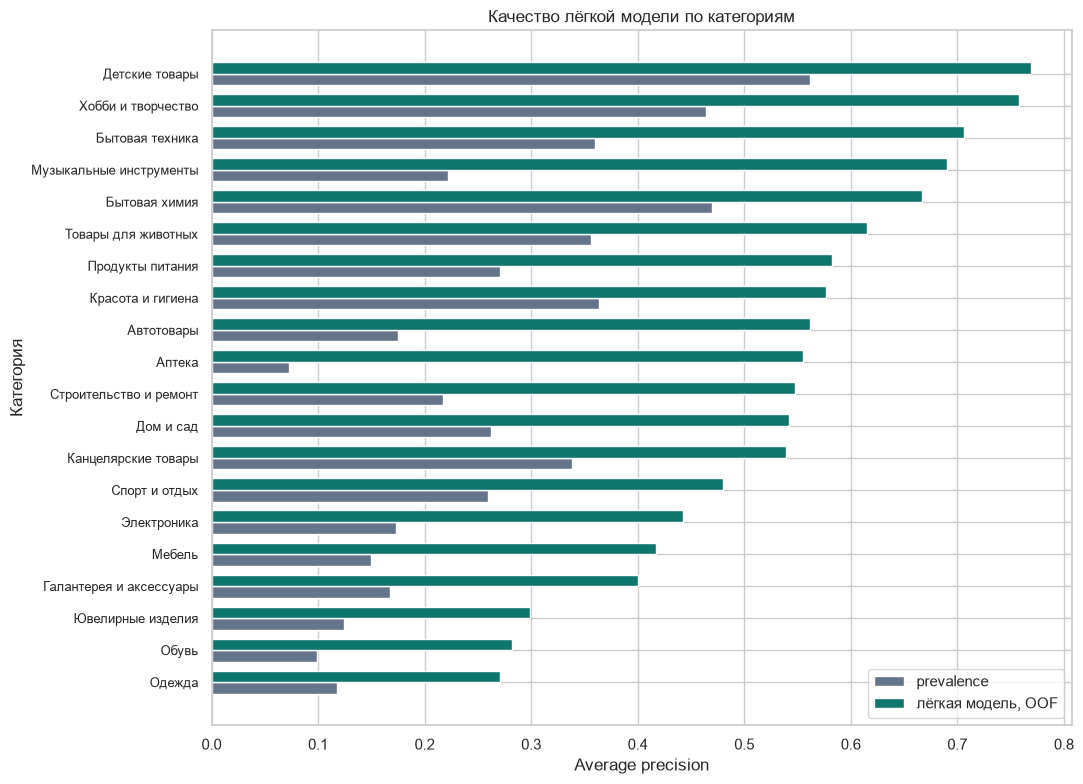


    Итог лёгкого OOF-бейзлайна: **macro AP = 0.5351**,
    overall AP = 0.6160. Разрыв между ними подтверждает, что
    overall-метрика завышает впечатление от модели. Слабее всего работают
    категории **Одежда**, **Обувь** и
    **Ювелирные изделия** — там особенно полезны cross-encoder,
    category-specific правила и работа с вариантами товара.
    

In [9]:
oof_scores, fold_scores = cross_validated_light_baseline(pair_data, component_groups)
light_macro_ap, light_category_ap = macro_average_precision(
    pair_data.targets, oof_scores, pair_data.categories
)
overall_oof_ap = average_precision_score(pair_data.targets, oof_scores)
display(fold_scores.style.format({"overall_ap": "{:.4f}"}))

comparison = category_summary[["pairs", "positive_rate"]].join(
    light_category_ap.rename("light_oof_ap")
).sort_values("light_oof_ap")
display(comparison.style.format({"positive_rate": "{:.4f}", "light_oof_ap": "{:.4f}"}))

fig, ax = plt.subplots(figsize=(11, 8))
positions = np.arange(len(comparison))
ax.barh(positions - .18, comparison["positive_rate"], height=.36,
        color=COLORS["negative"], label="prevalence")
ax.barh(positions + .18, comparison["light_oof_ap"], height=.36,
        color=COLORS["model"], label="лёгкая модель, OOF")
ax.set_yticks(positions, comparison.index, fontsize=9)
ax.set(title="Качество лёгкой модели по категориям", xlabel="Average precision", ylabel="Категория")
ax.legend()
fig.tight_layout()
plt.show()

display(Markdown(
    f'''
    Итог лёгкого OOF-бейзлайна: **macro AP = {light_macro_ap:.4f}**,
    overall AP = {overall_oof_ap:.4f}. Разрыв между ними подтверждает, что
    overall-метрика завышает впечатление от модели. Слабее всего работают
    категории **{comparison.index[0]}**, **{comparison.index[1]}** и
    **{comparison.index[2]}** — там особенно полезны cross-encoder,
    category-specific правила и работа с вариантами товара.
    '''
))

## 7. Уверенные ошибки лёгкой модели

In [10]:
hard_negatives, hard_positives = hard_examples(
    items, matches, pair_data, oof_scores, count=8
)
display(Markdown("### Отрицательные пары с высоким score"))
display(hard_negatives)
display(Markdown("### Положительные пары с низким score"))
display(hard_positives)

### Отрицательные пары с высоким score

,id1,id2,category,target,oof_score,name1,name2
0,223338381301,128849051272,Музыкальные инструменты,0,0.9602,"sw1020-4 губная гармошка, swan","sw1020-4 губная гармошка, swan"
1,850403534422,661425023728,Продукты питания,0,0.9577,гвоздика kotanyi целая 18 г,гвоздика kotanyi целая 18 г
2,60129692857,335007491770,Музыкальные инструменты,0,0.9480,flight fbg-1009 чехол для классической гитары,flight fbg-1009 чехол для классической гитары
3,721554506270,764504338038,Детские товары,0,0.9459,машинка металлическая uni-fortune rmz city 1:64 mercedes-benz c63 s amg coupe 2019,машинка металлическая uni-fortune rmz city 1:64 mercedes-benz c63 s amg coupe 2019
4,764504337207,833223667528,Детские товары,0,0.9448,"кукла коллекционная китаянка в национальном платье 32х12,5х12,5 см","кукла коллекционная ""китаянка в национальном платье"" 32х12,5х12,5 см"
5,704374727803,549755928728,Продукты питания,0,0.9430,соус mivimex перцовый 200 г,соус mivimex перцовый 200 г
6,171798771536,111669197956,Продукты питания,0,0.9428,жокей карамель кофейный напиток 3в1 10 стиков (комплект 8 шт.) 6013010,жокей карамель кофейный напиток 3в1 10 стиков (комплект 8 шт.) 6013010
7,824633755474,747324348134,Детские товары,0,0.9398,"мягкая игрушка abtoys домашние любимцы собачка хаски, 15 см","мягкая игрушка abtoys домашние любимцы собачка хаски, 15 см"


### Положительные пары с низким score

,id1,id2,category,target,oof_score,name1,name2
0,472446408617,566935808036,Аптека,1,0.0047,очки с футляром-змейка melorsch мод. 2110 цвет 6 с линзами ecoplus 1.56 hmc -6.00 рц 60-62,очки с футляром-змейка melorsch мод. 2110 цвет 6 с линзами ecoplus 1.56 hmc -8.00 рц 58-60
1,678604870304,558345858654,Электроника,1,0.0074,tecno / ноутбук для учёбы и дома для работы техно 16гб/512гб,"tecno megabook s1 ноутбук 15.6"", intel core i5-1240p, ram 16 гб, ssd, intel iris xe graphics, се..."
2,188978687709,403726961032,Аптека,1,0.0092,очки mien мод. 729 цвет 7 с линзами glance cr-39 -3.75 рц 64-66,очки mien мод. 797 цвет 7 с линзами glance cr-39 -3.75 рц 64-66
3,506806206119,352187342893,Аптека,1,0.0094,компьютерные очки для чтения с футляром-змейка dacchi мод. 32544 цвет 8 с линзами romeo 1.56 blu...,очки для чтения с футляром-змейка dacchi мод. 32544 цвет 8 с линзами ecoplus 1.50 uc +0.75 рц 68-70
4,481036411489,721554526402,Обувь,1,0.0095,кеддхаус / джорданы,кроссовки nike jordan skills (nike)
5,566935720471,51539658596,Аптека,1,0.0100,"alcon контактные линзы air optix plus hydraglyde, 6 шт., -7.50 / 8.6/ 1 месяц",alcon / мультифокальные линзы air optix plus hydraglyde -7.50 high
6,309237752594,627065337653,Строительство и ремонт,1,0.0115,душевой уголок abber schwarzer diamant ag30100h-s50-s50,душевой уголок abber schwarzer diamant ag30110h-s50-s50
7,335007491178,34359841539,Аптека,1,0.0124,компьютерные очки glodiatr с футляром мод. 1808 цвет 8 с флагманскими линзами glance digital 1.5...,очки glodiatr с футляром мод. 1808 цвет 8 с флагманскими линзами glance 1.56 hmc/emi +1.50 рц 60-62


Уверенные ошибки показывают два режима. У отрицательных пар часто почти
идентичны названия: различие может находиться в атрибутах/варианте либо быть
спорным случаем разметки. У положительных пар встречаются заметно разные
формулировки и, иногда, конфликтующие числа. Именно эти срезы стоит отдавать
на ручной аудит и использовать для hard-negative mining. Нельзя автоматически
считать их ошибками людей без просмотра полного контекста.

## 8. Предлагаемая архитектура решения

### Cross-encoder

- Начать с предложенного `Qwen3-Reranker-0.6B` как основного нелинейного
  scorer. Формат пары: категория, название, затем стабильная сериализация
  `ключ: значение`; наиболее полезные идентификаторы и размеры ставить раньше.
- Во время обучения случайно менять товары местами: score должен быть
  симметричен. Сэмплировать категории равномернее и выбирать checkpoint по
  macro AP, а не по loss/overall AP.
- Сначала ограничить длину 256–384 токенами и замерить curve
  `качество — pairs/sec`; длинные хвосты attributes нельзя молча обрезать до
  того, как артикулы, бренд, модель, размер и комплектация вынесены в начало.
- Делать hard-negative mining из уверенных ошибок лёгкой модели и текущего
  cross-encoder. Отдельно проверить пары с одинаковым названием и конфликтом
  числовых/variant-атрибутов.

### Лёгкая ветка

- Расширить текущие признаки: word/character TF-IDF cosine, BM25-подобные
  overlaps, нормализованные единицы измерения, бренд, артикул/OEM/EAN,
  модель, цвет, размер и комплектация. Ключи атрибутов нормализовать через
  словарь синонимов.
- Обучить CatBoost/LightGBM или компактную логистическую модель с
  category-specific взаимодействиями. Она полезна как быстрый baseline,
  второй независимый взгляд ансамбля и gate для дорогого scorer.
- Осторожно использовать high-precision правила. Точное имя и даже бренд
  сами по себе недостаточны; правила должны учитывать конфликты варианта.

### Ансамбль и каскад

- Собирать только OOF-предсказания базовых моделей и учить небольшой stacker
  на чистой ручной разметке. В качестве входов: cross-encoder logit, лёгкий
  score, identifier/variant flags и категория.
- Сравнить один глобальный stacker с category-wise калибровкой. Оптимизировать
  macro AP; бинарный threshold для метрики не нужен — в submit следует писать
  непрерывный score.
- Для скорости пропускать через cross-encoder только «серую зону» лёгкой
  модели. Крайним случаям назначать согласованные непрерывные scores, чтобы
  не разрушить ранжирование. Любой cascade валидировать одновременно по
  macro AP и wall-clock на объёмах Check/Public/Private.

### Когда появятся 11 млн LLM-размеченных пар

- Проверить совпадения и конфликты с ручной выборкой до объединения.
- Использовать LLM-разметку для pretraining/distillation с меньшим весом или
  confidence weights, затем fine-tune только на human labels.
- Чистый component-disjoint human holdout не использовать ни для отбора
  псевдометок, ни для настройки правил. Сравнить обучение на human-only,
  LLM→human и совместную смесь.
- Аудитировать disagreement: cross-encoder, лёгкая модель и LLM-метка. Это
  даст приоритетный список для повторной открытой LLM-разметки/ручной проверки.

### Скорость и воспроизводимость

- Один раз нормализовать и токенизировать уникальные товары, затем собирать
  пары по ID. Батчи группировать по длине, использовать dynamic padding и
  BF16/квантизацию только после замера потери macro AP.
- Хранить версии данных, seed, split-компоненты, конфиг сериализации и OOF
  predictions. Тренировочный и контейнерный inference-код должны использовать
  один и тот же preprocessor.
- Перед отправкой запускать локальный контрактный тест: все входные пары
  сохранены ровно один раз, столбцы строго `id1,id2,predict`, score конечный,
  контейнер работает без сети.

## 9. Приоритет экспериментов

In [11]:
experiment_plan = pd.DataFrame([
    ["E0", "Текущие RapidFuzz/JSON признаки + HGB", "Воспроизводимая нижняя граница", "macro AP, CPU pairs/s"],
    ["E1", "Char+word TF-IDF + числовые/ID/variant признаки", "Сильный дешёвый scorer", "macro AP, latency, RAM"],
    ["E2", "Qwen3-Reranker-0.6B, human-only, 256 токенов", "Основной cross-encoder baseline", "macro AP, GPU pairs/s"],
    ["E3", "Сериализация/длина 128–512 + category-balanced sampler", "Найти качество/скорость", "macro AP × category, pairs/s"],
    ["E4", "LLM pretrain → human fine-tune", "Использовать 11 млн шумных меток", "Δ macro AP к E2"],
    ["E5", "OOF stacker: cross-encoder + TF-IDF + эвристики", "Стабильный ансамбль", "OOF macro AP"],
    ["E6", "Gate серой зоны + BF16/INT8", "Уложиться в 6/13 минут", "macro AP, wall-clock, archive size"],
], columns=["ID", "Эксперимент", "Цель", "Главные измерения"]).set_index("ID")
display(experiment_plan)

category_summary.to_csv(REPORT_DIR / "category_summary.csv")
feature_scores.to_csv(REPORT_DIR / "univariate_feature_scores.csv")
comparison.to_csv(REPORT_DIR / "light_baseline_by_category.csv")
with (REPORT_DIR / "eda_summary.json").open("w", encoding="utf-8") as file:
    json.dump({
        "items": len(items),
        "pairs": len(matches),
        "positives": int(pair_data.targets.sum()),
        "positive_rate": float(pair_data.targets.mean()),
        "macro_prevalence": float(prevalence_macro),
        "light_oof_macro_ap": float(light_macro_ap),
        "light_oof_overall_ap": float(overall_oof_ap),
    }, file, ensure_ascii=False, indent=2)

,Эксперимент,Цель,Главные измерения
ID,,,
E0,Текущие RapidFuzz/JSON признаки + HGB,Воспроизводимая нижняя граница,"macro AP, CPU pairs/s"
E1,Char+word TF-IDF + числовые/ID/variant признаки,Сильный дешёвый scorer,"macro AP, latency, RAM"
E2,"Qwen3-Reranker-0.6B, human-only, 256 токенов",Основной cross-encoder baseline,"macro AP, GPU pairs/s"
E3,Сериализация/длина 128–512 + category-balanced sampler,Найти качество/скорость,"macro AP × category, pairs/s"
E4,LLM pretrain → human fine-tune,Использовать 11 млн шумных меток,Δ macro AP к E2
E5,OOF stacker: cross-encoder + TF-IDF + эвристики,Стабильный ансамбль,OOF macro AP
E6,Gate серой зоны + BF16/INT8,Уложиться в 6/13 минут,"macro AP, wall-clock, archive size"


## Итог

Данные технически чистые, но задача неоднородна по категориям и содержит
много сложных variant-level различий. Быстрые признаки уже дают осмысленный
baseline, однако их разрыв по категориям и уверенные ошибки показывают, что
основной прирост должен прийти от хорошо сериализованных атрибутов,
cross-encoder и OOF-ансамбля. Следующий практический шаг — E1 и E2 на одном
component-disjoint split с обязательным профилированием inference.